In [ ]:
# 모듈 설치
!pip install langchain langgraph langchain-community chromadb sqlite-utils

In [1]:
from langchain_community.llms import Ollama
from langchain_core.prompts import PromptTemplate
from langgraph.graph import StateGraph, END
from typing import TypedDict

In [2]:
# 1. 상태 정의
class AgentState(TypedDict):
    query: str              # 사용자 질의
    conditions: str         # 추출된 신체 상태/고민
    exercise_candidates: str  # 운동 후보 리스트
    result: str             # 최종 응답

In [3]:
# 2. LLM 초기화
llm = Ollama(model="exaone3.5:2.4b")

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33052\2031171905.py:2: LangChainDeprecationWarning: The class `Ollama` was deprecated in LangChain 0.3.1 and will be removed in 1.0.0. An updated version of the class exists in the :class:`~langchain-ollama package and should be used instead. To use it run `pip install -U :class:`~langchain-ollama` and import as `from :class:`~langchain_ollama import OllamaLLM``.
  llm = Ollama(model="exaone3.5:2.4b")


In [4]:
# 3. 에이전트 정의

# [추출 에이전트] 사용자 질문에서 신체 상태/고민 추출
extractor_prompt = PromptTemplate.from_template("""
사용자의 질문에서 신체 상태나 건강 고민에 해당하는 단어 또는 구를 추출하세요.
결과는 쉼표로 구분된 문자열로만 출력하세요. 설명은 하지 마세요.
질문: {query}
""")

def extractor_agent(state: AgentState):
    chain = extractor_prompt | llm
    conditions = chain.invoke({"query": state["query"]})
    return {**state, "conditions": conditions.strip()}

# [후보 에이전트] 신체 상태를 해결할 수 있는 운동 리스트 추출
matcher_prompt = PromptTemplate.from_template("""
다음 신체 상태 또는 건강 고민을 해결하는 데 효과적인 운동을 5가지 추천하세요.
운동 이름만 쉼표로 구분하여 출력하세요. 설명은 하지 마세요.
신체 상태: {conditions}
""")

def matcher_agent(state: AgentState):
    chain = matcher_prompt | llm
    candidates = chain.invoke({"conditions": state["conditions"]})
    return {**state, "exercise_candidates": candidates.strip()}

# [답변 에이전트] 신체 상태와 운동 리스트를 개조식으로 출력
answer_prompt = PromptTemplate.from_template("""
사용자의 신체 상태: {conditions}
추천 운동 목록: {exercise_candidates}

위 내용을 바탕으로 아래 형식의 개조식으로 답변을 작성하세요.

[현재 신체 상태]
- (상태 항목들)

[추천 운동]
- 운동명: 추천 이유 (1~2문장)
- ...

[실천 팁]
- (간단한 시작 조언 2~3가지)
""")

def answer_agent(state: AgentState):
    chain = answer_prompt | llm
    answer = chain.invoke({
        "conditions": state["conditions"],
        "exercise_candidates": state["exercise_candidates"]
    })
    return {**state, "result": answer.strip()}

============================== LangGraph 구조:


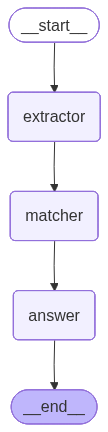

In [6]:
# 4. LangGraph 정의
graph = StateGraph(AgentState)
graph.add_node("extractor", extractor_agent)
graph.add_node("matcher", matcher_agent)
graph.add_node("answer", answer_agent)

graph.set_entry_point("extractor")
graph.add_edge("extractor", "matcher")
graph.add_edge("matcher", "answer")
graph.add_edge("answer", END)

app = graph.compile()

print("============================== LangGraph 구조:")
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [7]:
# 5. 실행 예시
# 질문 예시: "체력이 안좋고, 살이 계속 찌는데 어떤 운동을 할까?"
query = input("건강 고민을 입력하세요: ")
result = app.invoke({"query": query})

print("============================== 최종 응답:")
print(result["result"])

============================== 최종 응답:
## 신체 상태 및 운동 추천

**[현재 신체 상태]**
- 체력: 다소 낮음
- 살: 중간 수준 (개선 필요)
- 찌다: 최근 체중 증가 추세

**[추천 운동]**
- **버피 테스트:** 전신 운동으로 효과적인 칼로리 소모와 근력 강화에 탁월하며, 짧은 시간 내 높은 강도의 운동으로 효율적입니다.
- **점핑 잭:** 접근성이 높고 반복적인 동작으로 심폐 기능 향상에 도움이 됩니다. 간단한 동작으로 시작하기 좋습니다.
- **스텝 업 운동:** 다리 근력 강화와 균형 감각 향상에 효과적이며, 초보자도 쉽게 따라할 수 있습니다.
- **플랭크 변형:** 코어 근력 강화에 효과적이며, 플랭크 자체는 기본이지만 다리를 들어올리거나 팔로 지탱하는 등 변형 동작을 통해 더 많은 근육을 활성화시킬 수 있습니다.
- **스쿼트 세트:** 하체 근력 강화에 탁월하며, 다양한 난이도의 스쿼트 변형으로 체력 증진과 체중 감소에 도움이 됩니다.

**[실천 팁]**
1. **일정 시간, 일정 강도:** 처음엔 짧은 시간(10분 내외) 동안 고강도 운동으로 시작하여 점차 시간을 늘려갑니다.
2. **휴식과 회복:** 운동 후에는 충분한 휴식과 수분 섭취를 통해 근육 회복을 돕습니다.
3. **꾸준함 유지:** 주 3~4회 실시하고, 일관성을 유지하여 효과를 극대화합니다. 새로운 운동을 병행하면서도 기본 운동들을 꾸준히 실천하세요.
